# ECTP Slab Dataset

Characterizes the ECTP slab dataset used throughout this paper: slab identification,
thickness, layer count, slope angle, and weak layer properties.

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [ECTP Slab Identification](#2-ectp-slab-identification)
3. [Slab Characteristics](#3-slab-characteristics)
4. [Weak Layer Properties](#4-weak-layer-properties)
5. [Multiple Tests per Pit](#5-multiple-tests-per-pit)


In [8]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebook_utils import load_pits, create_ectp_slabs, hess_rcparams, SINGLE_COL, DOUBLE_COL, DPI

hess_rcparams()
FIGURES = 'figures'


## 1. Setup & Data Loading

In [9]:
pits = load_pits()
ectp_slabs = create_ectp_slabs(pits)

print(f'Loaded {len(pits):,} snow pits')
print(f'Created {len(ectp_slabs):,} ECTP slabs')


Loaded 50,278 snow pits
Created 14,776 ECTP slabs


## 2. ECTP Slab Identification

In [10]:
# Extract slab characteristics into a DataFrame
slab_rows = []
for slab in ectp_slabs:
    wl = slab.weak_layer

    def safe_float(v):
        if v is None:
            return None
        if hasattr(v, 'nominal_value'):
            return float(v.nominal_value)
        try:
            return float(v)
        except (TypeError, ValueError):
            return None

    slab_rows.append({
        'pit_id':           slab.pit_id,
        'slab_id':          getattr(slab, 'slab_id', None),
        'num_layers':       len(slab.layers),
        'total_thickness':  safe_float(slab.total_thickness),
        'slope_angle':      safe_float(slab.angle),
        'wl_depth':         safe_float(wl.depth_top)    if wl else None,
        'wl_thickness':     safe_float(wl.thickness)    if wl else None,
        'wl_hardness':      getattr(wl, 'hand_hardness', None) if wl else None,
        'wl_grain_form':    getattr(wl, 'grain_form', None)    if wl else None,
        'n_tests_in_pit':   getattr(slab, 'n_test_results_in_pit', None),
    })

df = pd.DataFrame(slab_rows)

n_pits_with_ectp = df['pit_id'].nunique()
print(f'Total ECTP slabs:       {len(df):>7,}')
print(f'Pits with ECTP slab(s): {n_pits_with_ectp:>7,} ({n_pits_with_ectp/len(pits):.1%} of all pits)')
print(f'Avg slabs per pit:      {len(df)/n_pits_with_ectp:>7.2f}')


Total ECTP slabs:        14,776
Pits with ECTP slab(s):  12,347 (24.6% of all pits)
Avg slabs per pit:         1.20


## 3. Slab Characteristics

In [11]:
# Summary statistics
for col, label, unit in [
    ('total_thickness', 'Slab thickness', 'cm'),
    ('num_layers',      'Layers per slab', ''),
    ('slope_angle',     'Slope angle',    '°'),
]:
    s = df[col].dropna()
    print(f'{label}: n={len(s):,}  mean={s.mean():.1f}{unit}  median={s.median():.1f}{unit}  '
          f'range=[{s.min():.1f}, {s.max():.1f}]{unit}')


Slab thickness: n=14,776  mean=48.6cm  median=45.0cm  range=[0.1, 253.0]cm
Layers per slab: n=14,776  mean=3.9  median=4.0  range=[1.0, 18.0]
Slope angle: n=13,715  mean=26.5°  median=27.0°  range=[0.0, 90.0]°


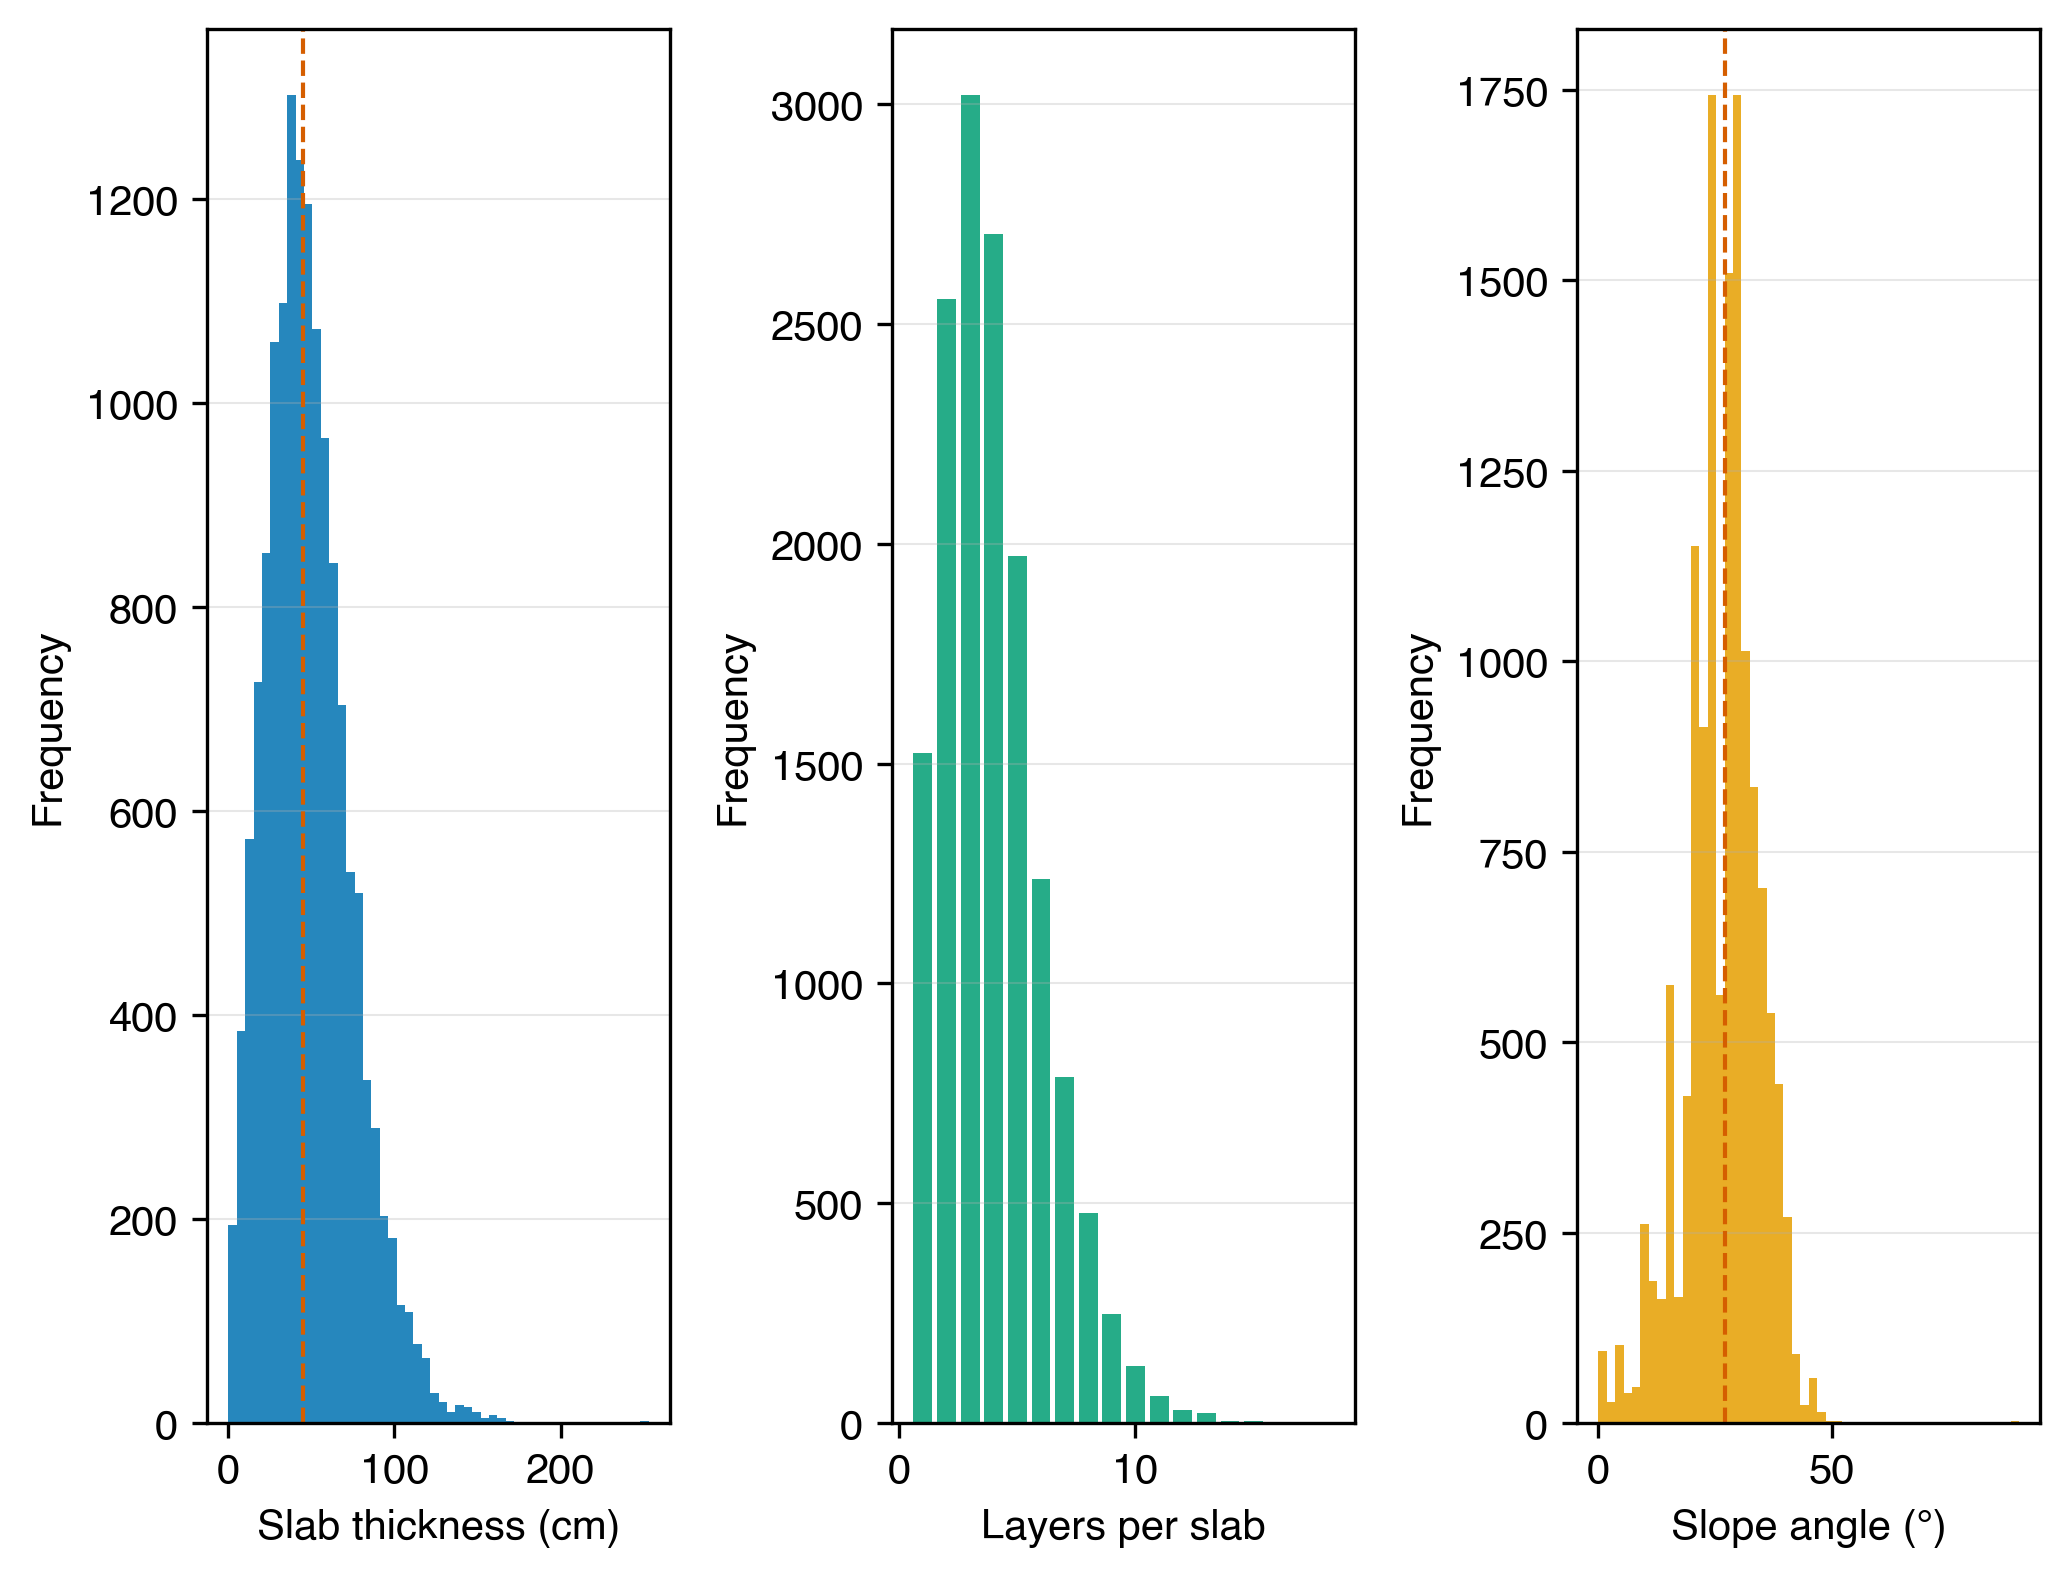

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL, SINGLE_COL * 1.6))

# Slab thickness
thick = df['total_thickness'].dropna()
axes[0].hist(thick, bins=50, color='#0072B2', alpha=0.85, edgecolor='none')
axes[0].axvline(thick.median(), color='#D55E00', linewidth=1.0, linestyle='--')
axes[0].set_xlabel('Slab thickness (cm)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3, linewidth=0.5)

# Layers per slab
lc = df['num_layers'].value_counts().sort_index()
axes[1].bar(lc.index, lc.values, color='#009E73', alpha=0.85, edgecolor='none')
axes[1].set_xlabel('Layers per slab')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3, linewidth=0.5)

# Slope angle
angle = df['slope_angle'].dropna()
axes[2].hist(angle, bins=50, color='#E69F00', alpha=0.85, edgecolor='none')
axes[2].axvline(angle.median(), color='#D55E00', linewidth=1.0, linestyle='--')
axes[2].set_xlabel('Slope angle (°)')
axes[2].set_ylabel('Frequency')
axes[2].grid(axis='y', alpha=0.3, linewidth=0.5)

fig.tight_layout()
fig.savefig(f'{FIGURES}/dataset_ectp_slab_characteristics.png', dpi=DPI, bbox_inches='tight')
plt.show()


## 4. Weak Layer Properties

In [13]:
# Weak layer grain form distribution
GRAIN_FORM_LABELS = ['PP','DF','RG','FC','DH','SH','MF','IF']
wl_gf = df['wl_grain_form'].dropna().str[:2]
gf_counts = wl_gf.value_counts(normalize=True).reindex(GRAIN_FORM_LABELS, fill_value=0)

print('Weak layer grain form distribution (ECTP failure layers):')
for code_, pct in gf_counts.items():
    if pct > 0:
        print(f'  {code_}: {pct:.1%}')

# Depth and thickness stats
for col, label, unit in [
    ('wl_depth',     'Weak layer depth',     'cm'),
    ('wl_thickness', 'Weak layer thickness', 'cm'),
]:
    s = df[col].dropna()
    if len(s):
        print(f'{label}: n={len(s):,}  mean={s.mean():.1f}{unit}  median={s.median():.1f}{unit}')


Weak layer grain form distribution (ECTP failure layers):
  PP: 2.0%
  DF: 7.2%
  RG: 7.3%
  FC: 51.1%
  DH: 13.6%
  SH: 7.2%
  MF: 9.0%
  IF: 2.6%
Weak layer depth: n=14,776  mean=48.7cm  median=45.0cm
Weak layer thickness: n=14,776  mean=14.8cm  median=10.0cm


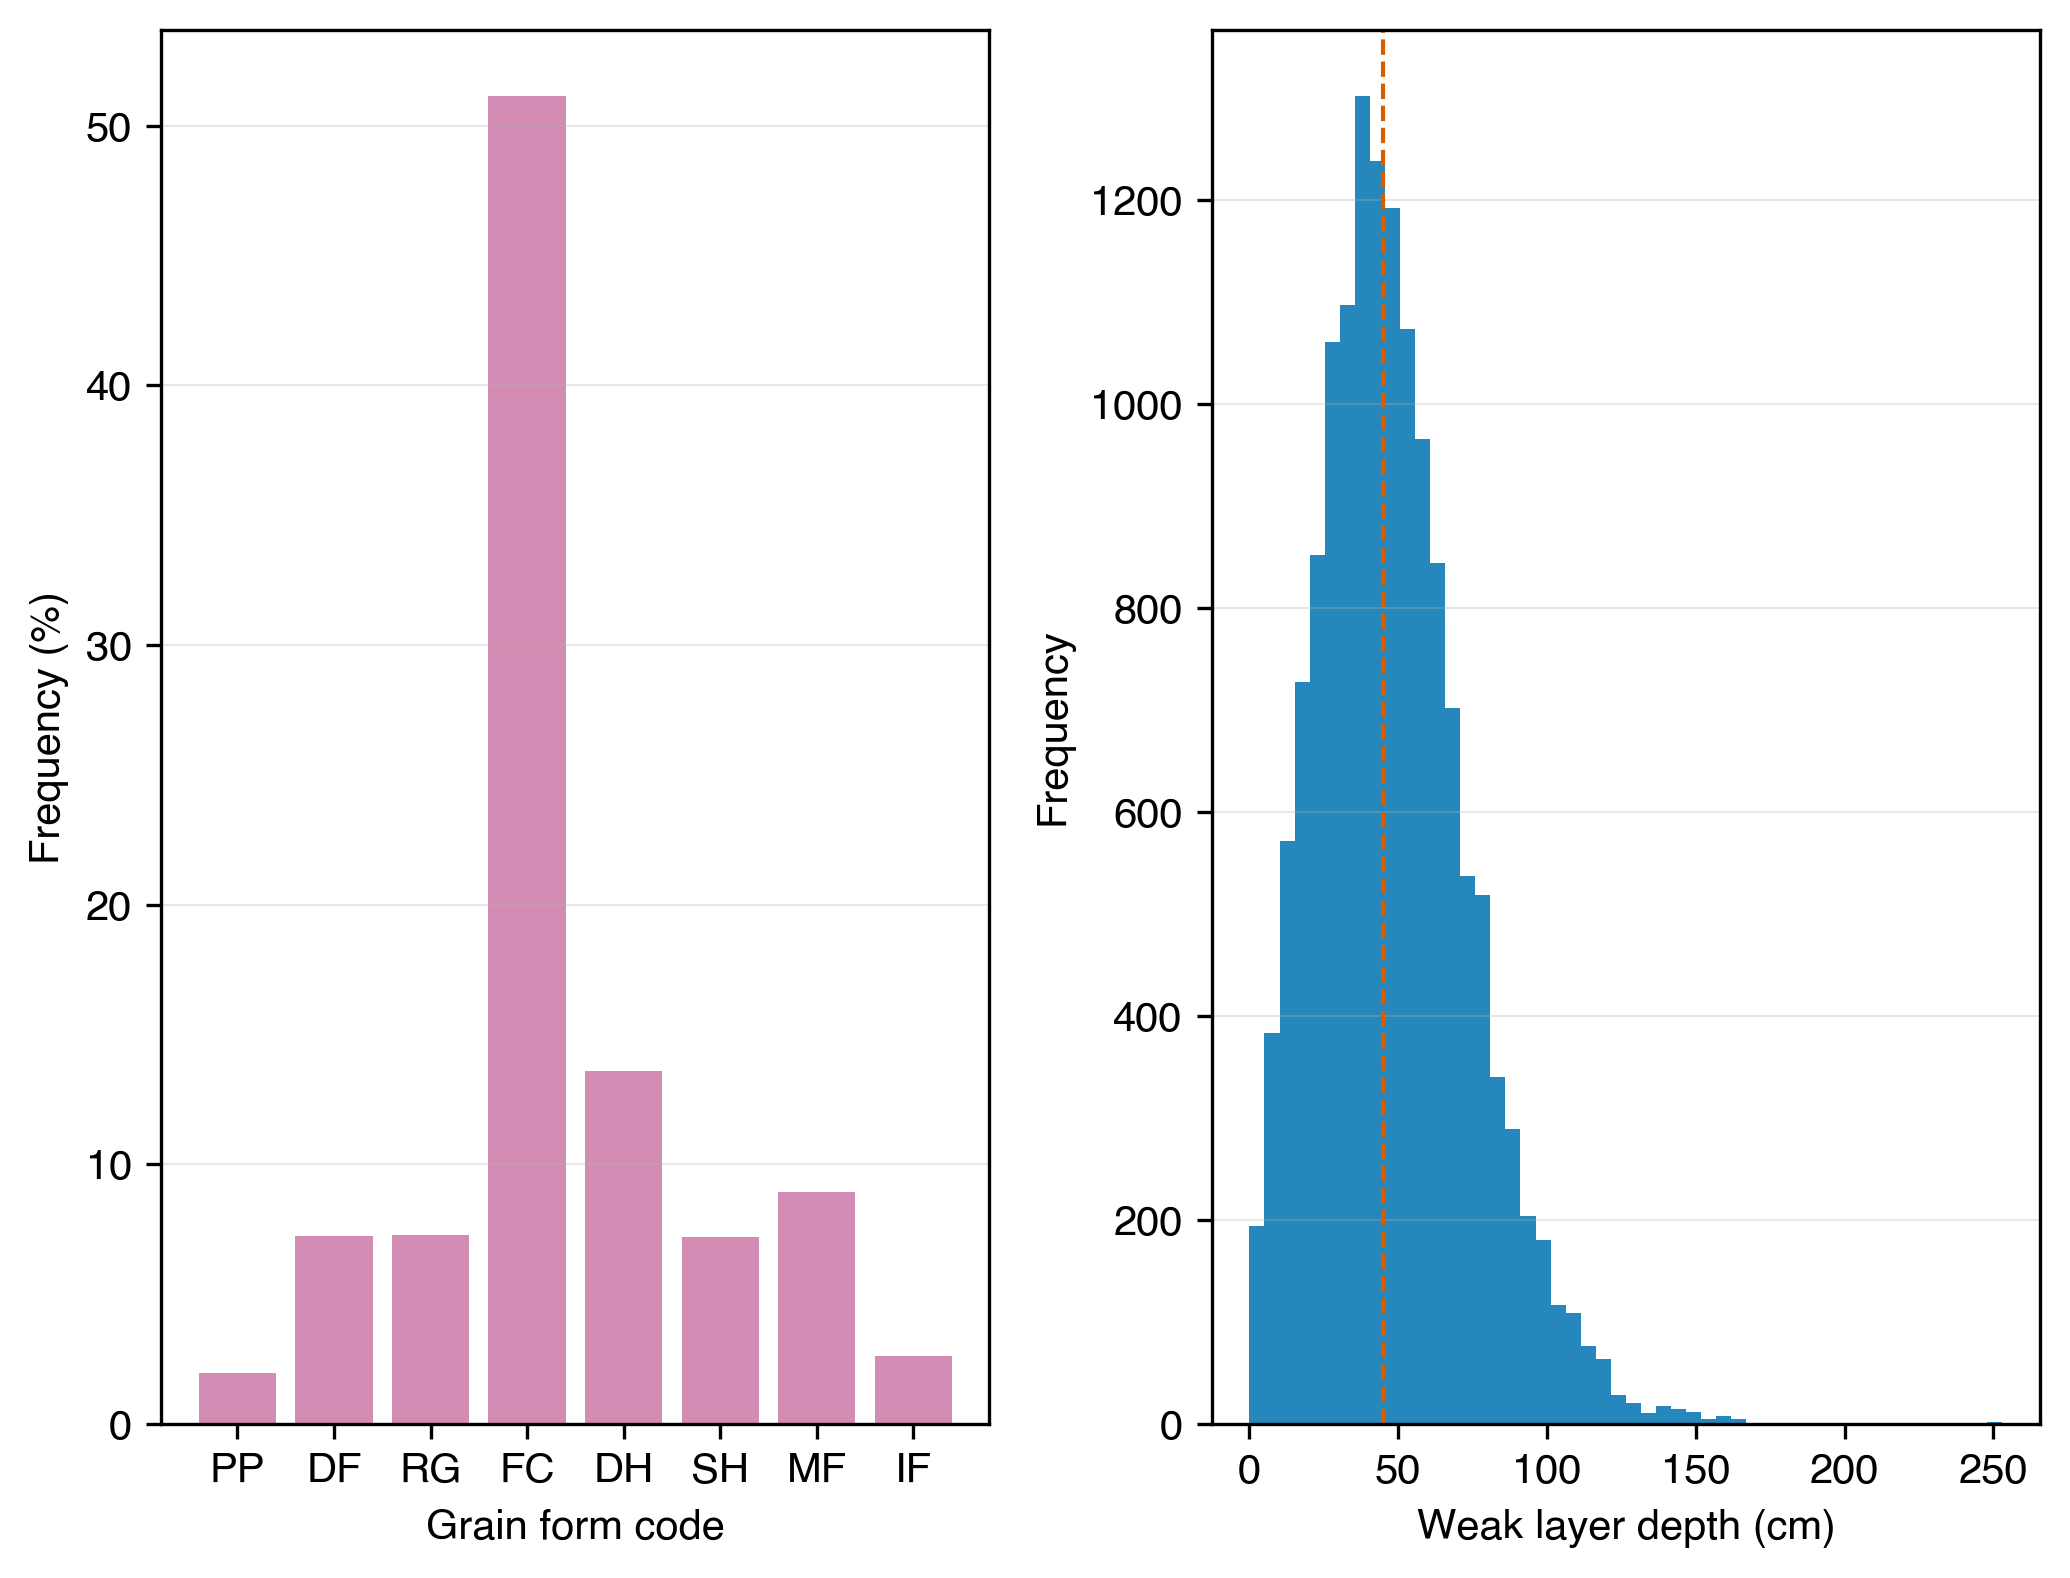

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, SINGLE_COL * 1.6))

# Grain form bar chart
axes[0].bar(gf_counts.index, gf_counts.values * 100, color='#CC79A7', alpha=0.85, edgecolor='none')
axes[0].set_xlabel('Grain form code')
axes[0].set_ylabel('Frequency (%)')
axes[0].grid(axis='y', alpha=0.3, linewidth=0.5)

# Weak layer depth histogram
wl_depth = df['wl_depth'].dropna()
axes[1].hist(wl_depth, bins=50, color='#0072B2', alpha=0.85, edgecolor='none')
axes[1].axvline(wl_depth.median(), color='#D55E00', linewidth=1.0, linestyle='--')
axes[1].set_xlabel('Weak layer depth (cm)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3, linewidth=0.5)

fig.tight_layout()
fig.savefig(f'{FIGURES}/dataset_ectp_weak_layer.png', dpi=DPI, bbox_inches='tight')
plt.show()


## 5. Multiple Tests per Pit

In [15]:
n_tests_col = df['n_tests_in_pit'].dropna()
if len(n_tests_col):
    multi = (n_tests_col > 1).sum()
    total_pits_ectp = df['pit_id'].nunique()
    print(f'Pits with multiple ECTP tests: {multi:,} ({multi/total_pits_ectp:.1%})')
    tests_dist = n_tests_col.astype(int).value_counts().sort_index()
    print('Distribution of ECTP tests per pit:')
    for n_tests, count in tests_dist.items():
        print(f'  {n_tests} test(s): {count:,} slabs')
else:
    print('n_tests_in_pit not available in this Slab version.')


Pits with multiple ECTP tests: 4,622 (37.4%)
Distribution of ECTP tests per pit:
  1 test(s): 10,154 slabs
  2 test(s): 3,775 slabs
  3 test(s): 634 slabs
  4 test(s): 161 slabs
  5 test(s): 46 slabs
  6 test(s): 6 slabs
